# Basic

In [1]:
import os
import pickle
import multiprocessing as mp
import tqdm
import numpy as np
import networkx as nx

import json
import polars as pl

import src.graph_tokenizer_gd_tree_dev.config as config
import src.graph_tokenizer_gd_tree_dev.tokenizer as tokenizer
import src.graph_tokenizer_gd_tree_dev.eval as eval
import src.graph_tokenizer_gd_tree_dev.graph_fct as graph_fct
import src.graph_tokenizer_gd_tree_dev.classical_selectors as classical_selectors

In [2]:
with open(config.TimelineData().used_cpt) as f:
    data = json.load(f)

rows = []
for category, terms in data.items():
    if isinstance(terms, dict):
        for term, label in terms.items():
            rows.append({"category": category, "term": term, "label": label})
    elif isinstance(terms, list):
        for term in terms:
            rows.append({"category": category, "term": term, "label": None})
    else:
        rows.append({"category": category, "term": None, "label": terms})

df = pl.DataFrame(rows)

df_concepts = pl.read_parquet(config.BasicConfig().concept_path, columns=["label", "id"])
df_mapped_ia_cohort = df.join(df_concepts, left_on="term", right_on="label", how="left").drop_nulls()


In [3]:
concepts_of_interest = df_mapped_ia_cohort["id"].unique().to_list()
concepts_of_interest

['395821003',
 '30188007',
 '19133005',
 '387137007',
 '1339069001',
 '258794004',
 '229819007+363898005',
 '230746009',
 '96306007',
 '398858004',
 '395960002',
 '405525004',
 '373572006:{246090004=398192003}',
 '700379002',
 '387207008',
 '399211009:{246090004=164918000}',
 '698090000',
 '38341003+395112001',
 '700378005',
 '424310002',
 '427515002',
 '391897002',
 '398192003+73211009',
 '94225005',
 '412432007',
 '386873009',
 '126965008',
 '372916001',
 '111287006',
 '700000006',
 '258826003',
 '64715009+698247007',
 '108476002',
 '48782003',
 '398192003+82423001',
 '365981007',
 '702975009',
 '170578008',
 '386872004+387525002',
 '399211009:{246090004=164916001}',
 '200148001+200151008',
 '15167005',
 '278152006',
 '395439003',
 '387078006',
 '771462006',
 '372877000',
 '733139004',
 '387457003',
 '46177005+82525005',
 '61586001',
 '302383004',
 '420654006',
 '372826007+386863007',
 '262952002',
 '24551003',
 '24624008',
 '278147001',
 '104931000119100',
 '387584000',
 '372501008'

# build the case-study candidate graph (D-hop ego-graph union over `concepts_of_interest`)

Same construction as 6.1, but centered on the curated variables, not the full cohort trajectory vocab.

In [4]:
with open(config.ProcessedGraph().id_to_label, "rb") as f:  # global concept_id -> label map, not M-specific -- reuse the main pipeline's
    id_to_label = pickle.load(f)

D = config.TokenizerParam().max_dist_candidate

df_relations = pl.read_parquet(config.BasicConfig().relation_path)
df_relations = df_relations.filter(~pl.col("dst.id").is_in(config.TokenizerParam().exclude_cpt))

whole_graph = graph_fct.build_relations_graph(df_relations, col_src="src.id", col_dst="dst.id", col_relation="relation")
combined_subgraphs = graph_fct.get_combined_subgraphs_from_nodes(whole_graph, concepts_of_interest, max_distance=D)
adj = tokenizer.build_out_adjacency(combined_subgraphs)

print(f"D={D}   curated concepts to tokenize: {len(concepts_of_interest):,}   "
      f"candidate graph: {combined_subgraphs.number_of_nodes():,} nodes, {combined_subgraphs.number_of_edges():,} edges")

D=3   curated concepts to tokenize: 268   candidate graph: 1,633 nodes, 3,901 edges


# reselect candidate tokens against `concepts_of_interest`

Same 3 lambdas (greedy tree) + personalized_pagerank + discrete_set_cover as 6.1, but ranked
fresh here instead of reusing the cohort-wide lists in `config.IACandidateLists()` -- those
were selected to cover the full trajectory vocab `M`, not this curated set of variables.

In [5]:
Ks = np.arange(50, 270, 20)  # same grid as 6.1's selection sweep
K_TARGET = int(Ks.max())        # rank exactly as many candidates as the k grid below will ever slice

ranked_tokens = {}
for lam in [0.6, 0.8, 1.0]:
    selector = tokenizer.LazyGreedyTokenSelector(combined_subgraphs, concepts_of_interest, D=D, lam=lam)
    history = selector.select(k=K_TARGET, n_jobs=-1)  # [(token, marginal_gain, cumulative_score), ...]
    ranked_tokens[f"lam_{lam}"] = [tok for tok, _, _ in history]

  seeding candidates: 0/1633  (12 workers)
  seeding candidates: 1633/1633  (12 workers)
[   1/250] token='229819007'     gain=0.01313  score=0.01313  opt<=0.02077  (re-evals=1, queue=1632)
[   2/250] token='734698003'     gain=0.01248  score=0.02561  opt<=0.04052  (re-evals=1, queue=1631)
[   3/250] token='441338003'     gain=0.01013  score=0.03574  opt<=0.05654  (re-evals=3, queue=1630)
[   4/250] token='260379002'     gain=0.00967  score=0.04541  opt<=0.07184  (re-evals=1, queue=1629)
[   5/250] token='64033007'      gain=0.00955  score=0.05496  opt<=0.08695  (re-evals=1, queue=1628)
[   6/250] token='387525002'     gain=0.00942  score=0.06438  opt<=0.10184  (re-evals=1, queue=1627)
[   7/250] token='734579009'     gain=0.00879  score=0.07316  opt<=0.11575  (re-evals=1, queue=1626)
[   8/250] token='113331007'     gain=0.00850  score=0.08166  opt<=0.12919  (re-evals=1, queue=1625)
[   9/250] token='38341003'      gain=0.00838  score=0.09004  opt<=0.14244  (re-evals=1, queue=1624)
[ 

In [6]:
personalized_pagerank = nx.pagerank(
    combined_subgraphs,
    personalization={m: 1 for m in concepts_of_interest if m in combined_subgraphs},
)
ranked_tokens["personalized_pagerank"] = [tok for tok, _ in sorted(personalized_pagerank.items(), key=lambda kv: kv[1], reverse=True)]

In [7]:
all_pairs = nx.all_pairs_shortest_path_length(combined_subgraphs)
distance_df = pl.DataFrame(
    [
        {"src_id": src, "dst_id": dst, "distance": dist}
        for src, lengths in all_pairs
        for dst, dist in lengths.items()
        if src != dst
    ]
)

set_cover_selector = classical_selectors.HardGreedySetCoverSelector(distance_df, concepts_of_interest, D)
history_set_cover = set_cover_selector.select(k=K_TARGET, verbose=False)
ranked_tokens["discrete_set_cover"] = [tok for tok, _, _ in history_set_cover]

print({name: len(toks) for name, toks in ranked_tokens.items()})

{'lam_0.6': 250, 'lam_0.8': 250, 'lam_1.0': 250, 'personalized_pagerank': 1633, 'discrete_set_cover': 250}


In [8]:
combos = [(name, k) for name in ranked_tokens for k in Ks]
print(f"{len(combos)} (method, k) combos")

55 (method, k) combos


# compare the reselected candidate methods

Same scoring machinery as 6.2 (`tokenizer.build_coverage_transition` + `_worker_coverage_score`,
parallelized over every `(method, k)`), but scored against `concepts_of_interest` instead of the
full cohort trajectory vocab -- so this measures how well each method covers the curated
variables specifically, not the whole cohort.

In [9]:
tasks = [((method_name, int(k)), ranked_tokens[method_name][:int(k)]) for method_name in ranked_tokens for k in Ks]

# transition matrix for semantic coverage -- depends on the graph only, not on any T, so build once and share
A, node_to_idx = tokenizer.build_coverage_transition(combined_subgraphs)

n_workers = os.cpu_count()
with mp.Pool(n_workers, initializer=tokenizer._init_coverage_worker,
             initargs=(A, node_to_idx, adj, concepts_of_interest, D, id_to_label)) as pool:
    task_results = pool.imap_unordered(tokenizer._worker_coverage_score, tasks, chunksize=4)
    comparison_rows = [
        {"method": method_name, "k": k, **metrics}
        for (method_name, k), metrics in tqdm.tqdm(task_results, total=len(tasks))
    ]

comparison_df = pl.DataFrame(comparison_rows)
comparison_df.write_parquet(f"{config.IAFeatures().path}candidate_comparison.parquet")

100%|██████████| 55/55 [00:00<00:00, 58.24it/s]


# comparison plot -- one subplot per metric, one line per method

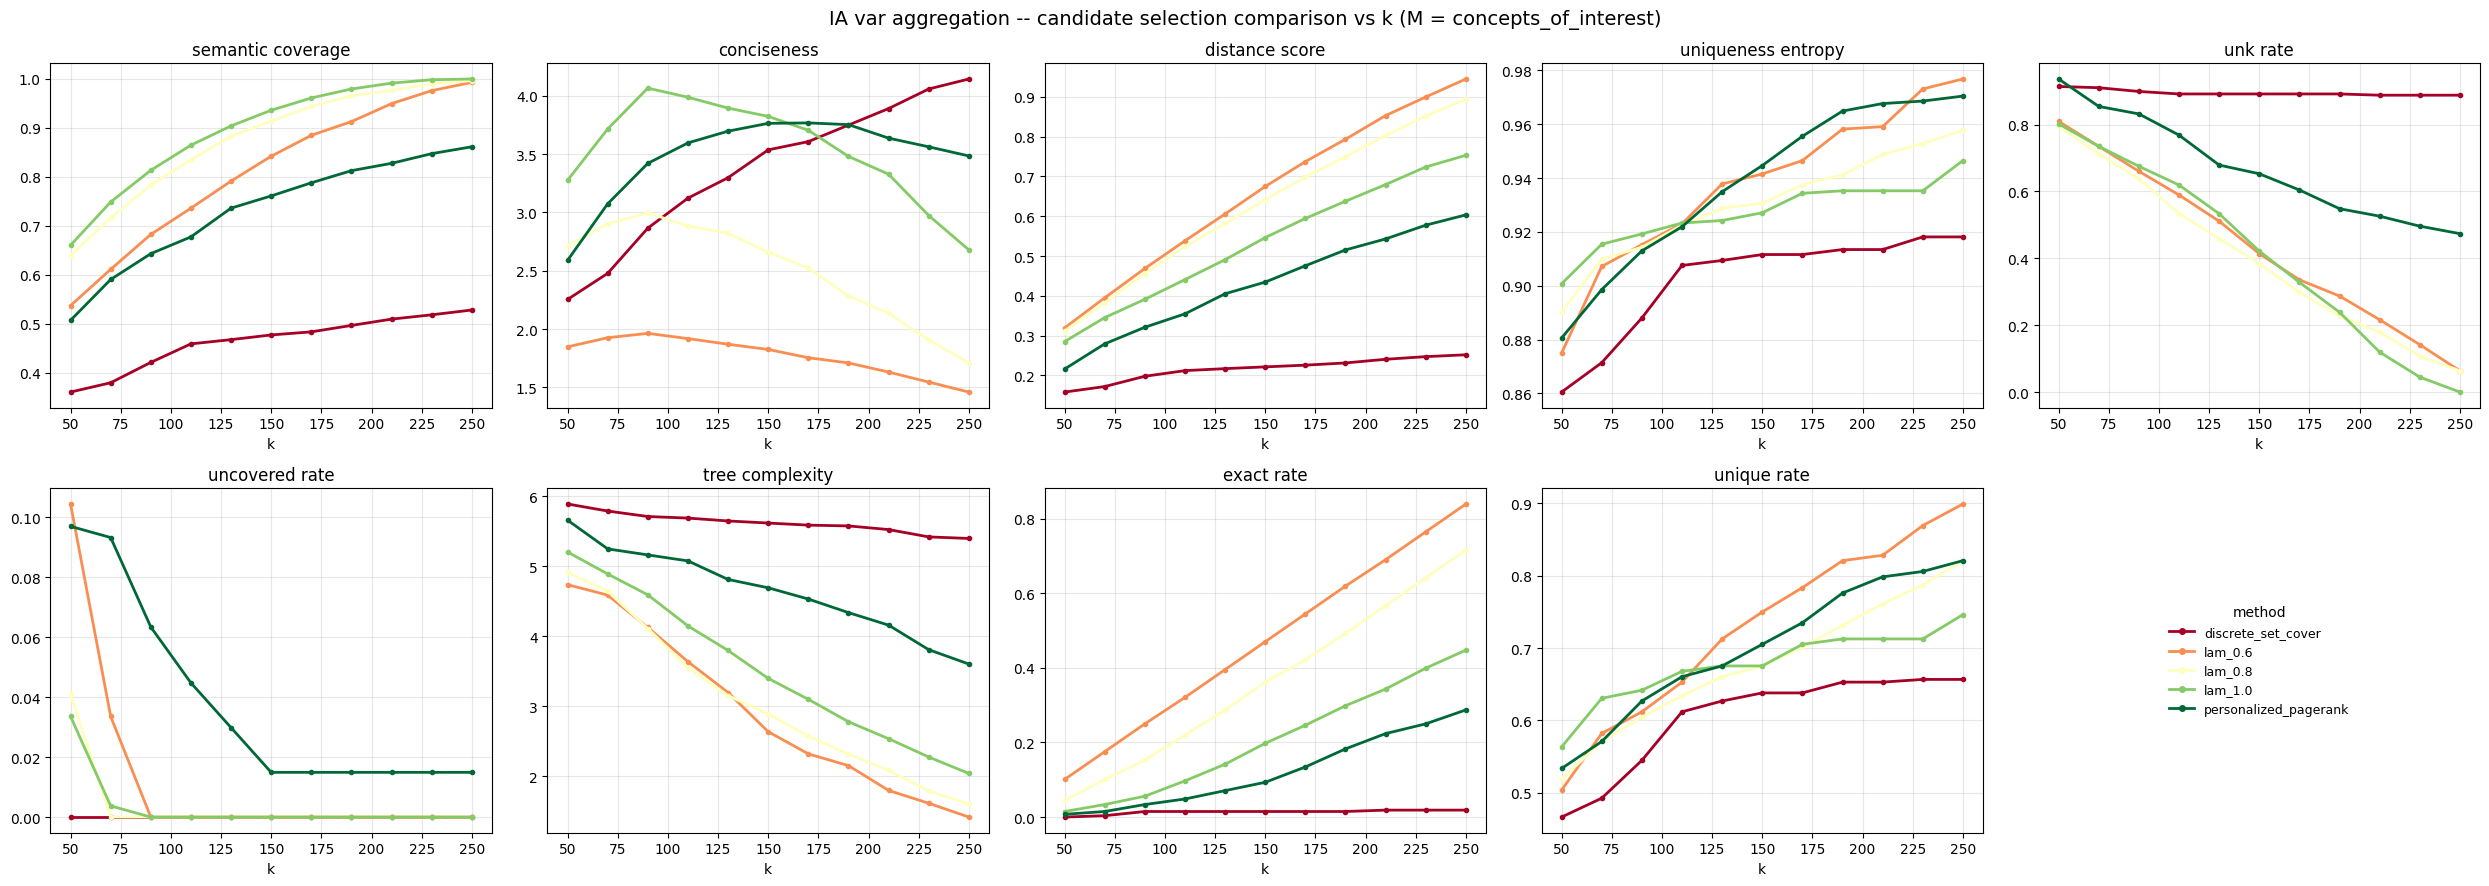

In [10]:
import matplotlib.pyplot as plt

metric_cols = ["semantic_coverage", "conciseness", "distance_score", "uniqueness_entropy",
               "unk_rate", "uncovered_rate", "tree_complexity", "exact_rate", "unique_rate"]

comparison_df = pl.read_parquet(f"{config.IAFeatures().path}candidate_comparison.parquet").sort(["method", "k"])
methods = comparison_df["method"].unique().sort().to_list()

# hue-varied ordinal ramp: red -> yellow -> green across all methods, fixed sorted order
cmap = plt.get_cmap("RdYlGn")
colors = {m: cmap(i / max(len(methods) - 1, 1)) for i, m in enumerate(methods)}

fig, axes = plt.subplots(2, 5, figsize=(25, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metric_cols):
    for method in methods:
        sub = comparison_df.filter(pl.col("method") == method)
        ax.plot(sub["k"], sub[metric], color=colors[method], linewidth=2, marker="o", markersize=3, label=method)
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("k")
    ax.grid(alpha=0.3)

axes[-1].axis("off")
handles = [plt.Line2D([0], [0], color=colors[m], lw=2, marker="o", markersize=4, label=m) for m in methods]
axes[-1].legend(handles=handles, loc="center", fontsize=9, title="method", frameon=False)

fig.suptitle("IA var aggregation -- candidate selection comparison vs k (M = concepts_of_interest)", fontsize=14)
fig.tight_layout()
plt.show()

# tokenize each curated concept (same `tokenize_all_rel` helper as 6.3) -- concept -> (tokens found, any-uncovered)

In [11]:
def concept_to_tokens_and_unk(c, T_set, D):
    tree = tokenizer.tokenize_all_rel(c, adj, T_set, D, id_to_label)
    contexts = list(eval._iter_contexts(tree))
    found = {tok for ctx in contexts for tok, _ in ctx.tokens}
    uncovered = any(ctx.uncovered for ctx in contexts)
    return found, uncovered

# for each (method, k), which reduced token(s) does each curated variable aggregate onto?

In [12]:
os.makedirs(config.IAFeatures().path, exist_ok=True)

df_concept_info = df_mapped_ia_cohort.select("category", "label", "id").unique(subset=["id"], keep="first")

rows = []
for method_name, k in tqdm.tqdm(combos):
    T_set = set(ranked_tokens[method_name][:k])

    for c in concepts_of_interest:
        found, uncovered = concept_to_tokens_and_unk(c, T_set, D)
        rows.append((method_name, k, c, ",".join(sorted(found)), uncovered))

df_var_agg = (
    pl.DataFrame(rows, schema=["method", "k", "id", "tokens", "uncovered"], orient="row")
    .join(df_concept_info, on="id", how="left")
)
df_var_agg.write_parquet(f"{config.IAFeatures().path}var_aggregation.parquet")

print(f"wrote var_aggregation.parquet: {df_var_agg.shape[0]:,} rows "
      f"({len(combos)} combos x {len(concepts_of_interest)} curated concepts)")

100%|██████████| 55/55 [00:00<00:00, 72.24it/s]


wrote var_aggregation.parquet: 14,740 rows (55 combos x 268 curated concepts)


# check k = 150 semantic share

In [19]:
K = 150
df_var_agg.filter(pl.col("k") == K).group_by("method", "label").agg("tokens", "id")

method,label,tokens,id
str,str,list[str],list[str]
"""lam_0.8""","""sickle_cell_disease""","[""127040003"", ""16402000""]","[""127040003"", ""16402000""]"
"""discrete_set_cover""","""hydrocephalus""","[""118934005,49755003"", ""118934005,118940003,49755003"", … ""282032007,49755003""]","[""230746009"", ""230745008"", … ""30753002""]"
"""discrete_set_cover""","""CKD""","[""1149388004,118972000,272520006"", ""1149388004,118972000,272520006"", … ""1149388004,118972000,272520006""]","[""700379002"", ""700378005"", … ""714152005""]"
"""personalized_pagerank""","""O+""","[""129265001,252314007,405824009""]","[""278147001""]"
"""lam_0.6""","""Ruptured cerebral aneurysm""","[""233983001""]","[""233983001""]"
…,…,…,…
"""lam_0.6""","""AB""","[""252314007,405824009""]","[""165743006""]"
"""lam_0.8""","""amlodipine""","[""386864001"", ""386864001,387525002,428304009"", … ""386864001,726711005,734551003""]","[""386864001"", ""770960003"", … ""386864001+386876001""]"
"""personalized_pagerank""","""statine""","[""372912004,734592007"", ""372912004,41175001,734592007"", … ""372912004,734592007""]","[""96306007"", ""387584000"", … ""373566006""]"


In [17]:
df_var_agg

method,k,id,tokens,uncovered,category,label
str,i64,str,str,bool,str,str
"""lam_0.6""",50,"""395821003""","""410942007,734551003""",true,"""PPI""","""PPI"""
"""lam_0.6""",50,"""30188007""","""255399007""",true,"""alpha1_antitrypsin_syndrome""","""alpha1_antitrypsin_syndrome"""
"""lam_0.6""",50,"""19133005""","""255399007""",true,"""neurofibromatosis""","""neurofibromatosis"""
"""lam_0.6""",50,"""387137007""","""410942007,734551003""",true,"""PPI""","""PPI"""
"""lam_0.6""",50,"""1339069001""","""372880004,734551003""",true,"""beta_blocker""","""beta_blocker"""
…,…,…,…,…,…,…
"""discrete_set_cover""",250,"""1348295004+289227000""","""118215003""",true,"""delivery""","""delivery"""
"""discrete_set_cover""",250,"""38341003""","""106063007,106239005,113257007,…",true,"""hypertension_labels""","""Essential hypertension"""
"""discrete_set_cover""",250,"""398192003+59927004""","""10200004,105721009,1290917001""",true,"""co-morbid conditions""","""co-morbid conditions"""
